#### 01、导入数据

In [1]:
import pandas as pd
import numpy as np
import jieba
import time

from pyecharts.charts import Bar,Line,Map,Page,Pie
from pyecharts import options as opts
from pyecharts.globals import SymbolType

In [2]:
df_tb = pd.read_csv(r'乐高淘宝数据.csv')
df_tb.head()

,goods_name,shop_name,price,purchase_num,location
0,乐高旗舰店官网悟空小侠系列80012孙悟,乐高官方旗舰店,1299.0,['867人付款'],浙江 嘉兴
1,LEGO乐高 71043收藏版哈利波特霍格沃兹城堡玩具礼物,天猫国际进口超市,3299.0,['259人付款'],浙江 杭州
2,LEGO乐高机械组布加迪42083粉丝收藏旗舰款玩具模型礼物,天猫国际进口超市,2799.0,['441人付款'],浙江 杭州
3,乐高旗舰店官网3月新品76895超级赛车系列法拉利赛车积木玩具男孩,乐高官方旗舰店,199.0,['358人付款'],浙江 嘉兴
4,乐高旗舰店官网3月新品得宝系列10921超级英雄实验室大颗粒益智,乐高官方旗舰店,299.0,['126人付款'],浙江 嘉兴


In [3]:
df_tb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4404 entries, 0 to 4403
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   goods_name    4404 non-null   object 
 1   shop_name     4404 non-null   object 
 2   price         4404 non-null   float64
 3   purchase_num  4404 non-null   object 
 4   location      4404 non-null   object 
dtypes: float64(1), object(4)
memory usage: 172.2+ KB


#### 02、数据处理
#####  处理步骤：
#####    1、去除重复值
#####    2、goods_name：暂不处理
#####    3、shop_name：暂不处理
#####    4、price：暂不处理
#####    5、purchase_num：提取人数
#####    6、计算销售额 = price * purchase_num
#####    7、location：提取省份

In [3]:
# 去除重复值
df_tb.drop_duplicates(inplace=True)

# 删除购买人数为空的记录
df_tb = df_tb[df_tb['purchase_num'].str.contains('人付款')]

# 重置索引
df_tb = df_tb.reset_index(drop=True)
df_tb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3411 entries, 0 to 3410
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   goods_name    3411 non-null   object 
 1   shop_name     3411 non-null   object 
 2   price         3411 non-null   float64
 3   purchase_num  3411 non-null   object 
 4   location      3411 non-null   object 
dtypes: float64(1), object(4)
memory usage: 133.4+ KB


In [4]:
# purchase_num处理
df_tb['purchase_num'] = df_tb['purchase_num'].astype(str)
df_tb['purchase_num'] = df_tb['purchase_num'].str.extract('(\\d+)').astype('int')


# 计算销售额
df_tb['sales_volume'] = df_tb['price'] * df_tb['purchase_num']

#location
df_tb['province'] = df_tb['location'].str.split(' ').str[0]
df_tb.head()

,goods_name,shop_name,price,purchase_num,location,sales_volume,province
0,乐高旗舰店官网悟空小侠系列80012孙悟,乐高官方旗舰店,1299.0,867,浙江 嘉兴,1126233.0,浙江
1,LEGO乐高 71043收藏版哈利波特霍格沃兹城堡玩具礼物,天猫国际进口超市,3299.0,259,浙江 杭州,854441.0,浙江
2,LEGO乐高机械组布加迪42083粉丝收藏旗舰款玩具模型礼物,天猫国际进口超市,2799.0,441,浙江 杭州,1234359.0,浙江
3,乐高旗舰店官网3月新品76895超级赛车系列法拉利赛车积木玩具男孩,乐高官方旗舰店,199.0,358,浙江 嘉兴,71242.0,浙江
4,乐高旗舰店官网3月新品得宝系列10921超级英雄实验室大颗粒益智,乐高官方旗舰店,299.0,126,浙江 嘉兴,37674.0,浙江


#### 03、数据可视化
##### 可视化目录：
#####   1、乐高销量排名top10店铺 - 条形图
#####   2、乐高产地数量排名top10 - 条形图
#####   3、乐高产地国内销量分布 - 地图
#####   4、价格分布 - 饼图
#####   5、不同价格区间的销量表现 - 饼图
#####   6、商品标题词云图 - 词云图

###### 乐高销量排名Top10淘宝店铺 - 条形图

In [5]:
shop_top10 = df_tb.groupby('shop_name')['purchase_num'].sum().sort_values(ascending=False).head(10)
shop_top10

shop_name
乐高官方旗舰店                28669
天猫超市                    7122
t_1480604179663zhou     7076
themusicman             7000
童趣互娱                    6722
草莓牛奶加冰                  6500
h543515750              5915
liji0904                4919
贝妮欧                     4175
konglone                3831
Name: purchase_num, dtype: int64

In [6]:
#条形图
#bar1 = Bar(init_opts=opts.InitOpts(width='1350px', height='750px'))
bar1 = Bar()
bar1.add_xaxis(shop_top10.index.tolist())
bar1.add_yaxis('', shop_top10.values.tolist())
bar1.set_global_opts(title_opts=opts.TitleOpts(title='乐高销量排名Top10淘宝店铺'),
                     xaxis_opts=opts.AxisOpts(axislabel_opts=opts.LabelOpts(rotate=-15)),
                     visualmap_opts=opts.VisualMapOpts(max_=28669)
                    )

# bar1.render_notebook()

from IPython.display import HTML

html_content = bar1.render_embed()  # 生成嵌入的HTML
HTML(html_content)

In [7]:
province_top10 = df_tb.province.value_counts()[:10]
province_top10

province
广东    1000
上海     960
北京     662
浙江     249
江苏     144
辽宁     116
天津     113
湖北      63
山东      33
美国      29
Name: count, dtype: int64

In [8]:
bar2 = Bar()
bar2.add_xaxis(province_top10.index.tolist())
bar2.add_yaxis('',province_top10.values.tolist())
bar2.set_global_opts(
    title_opts = opts.TitleOpts(title = '乐高产地数量排名top10'),
    visualmap_opts = opts.VisualMapOpts(max_=1000)
)
# bar2.render_notebook()

html_content2 = bar2.render_embed()  # 生成嵌入的HTML字符串
HTML(html_content2)  # 使用HTML显示

In [9]:
province_num = df_tb.groupby('province')['purchase_num'].sum().sort_values(ascending=False)

province_num[:10]

province
广东    172277
上海     49649
浙江     42537
北京     18003
江苏      5309
山东      3177
天津      2837
湖北      1130
福建       838
湖南       802
Name: purchase_num, dtype: int64

In [11]:
map1 = Map()
map1.add("",[list(z) for z in zip(province_num.index.tolist(),province_num.values.tolist())],
       maptype='china')
map1.set_global_opts(
    title_opts = opts.TitleOpts(title='国内各产地乐高销量分布图'),
    visualmap_opts = opts.VisualMapOpts(max_=172277)
)
# map1.render_notebook()

html_content3 = map1.render_embed()  
HTML(html_content3)


In [12]:
cut_bins = [0,50,100,200,300,500,1000,8888]
cut_labels = ['0~50元', '50~100元', '100~200元', '200~300元', '300~500元', '500~1000元', '1000元以上']

price_cut = pd.cut(df_tb['price'],bins=cut_bins,labels=cut_labels)
price_num = price_cut.value_counts()
price_num

price
0~50元        895
100~200元     701
50~100元      486
500~1000元    411
300~500元     370
200~300元     288
1000元以上      260
Name: count, dtype: int64

In [13]:
bar3 = Bar()
bar3.add_xaxis(['0~50元', '50~100元', '100~200元', '200~300元', '300~500元', '500~1000元', '1000元以上'])
bar3.add_yaxis('', [895, 486, 701, 288, 370, 411, 260])
bar3.set_global_opts(title_opts=opts.TitleOpts(title='不同价格区间的商品数量'),
                     visualmap_opts=opts.VisualMapOpts(max_=900))
bar3.render_notebook()

html_content4 = bar3.render_embed()  # 生成嵌入的HTML字符串
HTML(html_content4)

In [14]:
df_tb['price_cut'] = price_cut

cut_purchase = df_tb.groupby('price_cut',observed=False)['sales_volume'].sum()
cut_purchase

price_cut
0~50元         3276343.91
50~100元       4254628.19
100~200元      9163543.91
200~300元      4562817.64
300~500元      8885389.32
500~1000元     9250876.30
1000元以上      18742166.89
Name: sales_volume, dtype: float64

In [15]:
data_pair = [list(z) for z in zip(cut_purchase.index.tolist(), cut_purchase.values.tolist())]
# 绘制饼图
pie1 = Pie()
pie1.add('', data_pair, radius=['35%', '60%'])
pie1.set_global_opts(title_opts=opts.TitleOpts(title='不同价格区间的销售额整体表现'),
                     legend_opts=opts.LegendOpts(orient='vertical', pos_top='15%', pos_left='2%'))
pie1.set_series_opts(label_opts=opts.LabelOpts(formatter="{b}:{d}%"))
pie1.set_colors(['#EF9050', '#3B7BA9', '#6FB27C', '#FFAF34', '#D8BFD8', '#00BFFF', '#7FFFAA'])
pie1.render_notebook()

html_content5 = pie1.render_embed()  # 生成嵌入的HTML字符串
HTML(html_content5)

In [16]:
import re
import jieba

def get_cut_words(content_series):
    # 读入停用词表
    stop_words = []

    # 添加关键词 - 修复 add_word 方法调用
    my_words = ['乐高', '悟空小侠', '大颗粒', '小颗粒']
    for i in my_words:
        jieba.add_word(i, freq=1000)  # 添加频率参数

    # 自定义停用词
#     my_stop_words = []
#     stop_words.extend(my_stop_words)

    # 分词
    word_num = list(jieba.cut(content_series.str.cat(sep='。'), cut_all=False))

    # 条件筛选
    word_num_selected = [i for i in word_num if i not in stop_words and len(i)>=2]

    return word_num_selected


In [19]:
text = get_cut_words(content_series=df_tb['goods_name'])
text[:10]

['乐高', '旗舰店', '官网', '悟空小侠', '系列', '80012', '孙悟', 'LEGO', '乐高', '71043']

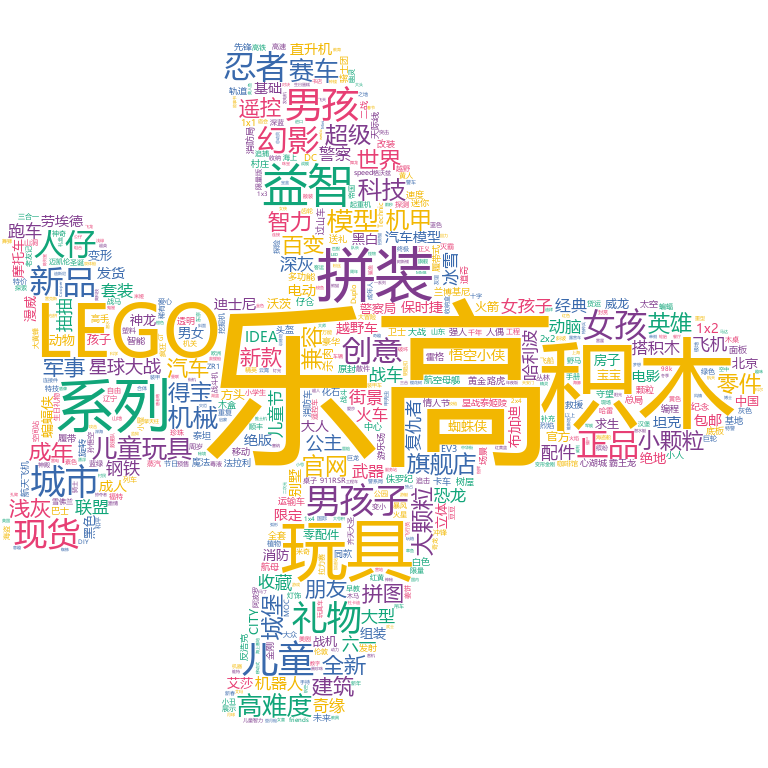

In [21]:
import stylecloud
from IPython.display import Image # 用于在jupyter lab中显示本地图片

from PIL import ImageDraw, ImageFont

if not hasattr(ImageDraw.ImageDraw, 'textsize'):
    def _text_size(self, text, font=None, *_, **__):
        left, top, right, bottom = (font or self.getfont()).getbbox(text)
        return right - left, bottom - top
    ImageDraw.ImageDraw.textsize = _text_size

# 绘制词云图
stylecloud.gen_stylecloud(
    text=' '.join(text),
    collocations=False,
    font_path=r'‪C:\Windows\Fonts\msyh.ttc',
    icon_name='fas fa-plane',
    size = 768,
    output_name='淘宝乐高标题词云图.png'
)
Image(filename='淘宝乐高标题词云图.png')

#### 04、乐高天猫旗舰店数据分析

In [22]:
df_tm = pd.read_csv(r'天猫乐高旗舰店数据.csv')
df_tm.head()

,title,age_range,price,sales_num,comment_num,color_cat
0,乐高哈利波特系列霍格沃茨城堡71043成人收藏,适用年龄范围：16+岁,3999.00,139,511,71043 霍格沃兹城堡
1,乐高旗舰店Ideas系列21319中央咖啡厅老友记收藏送礼,适用年龄16岁+,699.00,454,1299,无
2,乐高旗舰店官网2020年新品10269 哈雷戴维森®肥仔®摩托车成人收藏,NaN,999.00,276,509,无
3,乐高旗舰店官网2020年新品Ideas系列21320恐龙化石男女孩玩具礼物,NaN,599.00,359,524,无
4,乐高旗舰店官网10874智能蒸汽火车遥控轨道大颗粒益智积木玩具,适用年龄范围：2-5岁,549.00,806,2884,10874蒸汽智能火车


In [23]:
df_tm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   title        392 non-null    object
 1   age_range    334 non-null    object
 2   price        392 non-null    object
 3   sales_num    392 non-null    object
 4   comment_num  392 non-null    int64 
 5   color_cat    392 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.5+ KB


数据分析目录：
1、重复值处理
2、age_range：暂不处理
3、price：价格处理/类型转换
4、sales_num: 类型转换
5、color_cat：暂不处理

In [24]:
df_tm.drop_duplicates(inplace=True)

# 价格处理
def transform_price(x):
    if '-' in x:
        return (float(x.split('-')[1]) - float(x.split('-')[0]))/2
    else:
        return x

# 价格转换
df_tm['price'] = df_tm.price.apply(lambda x:transform_price(x)).astype('float')

# 使用平均值填充缺失值
df_tm['sales_num'] = df_tm.sales_num.replace('无',200)

#转换类型
df_tm['sales_num'] = df_tm.sales_num.astype('int')
df_tm.head()

,title,age_range,price,sales_num,comment_num,color_cat
0,乐高哈利波特系列霍格沃茨城堡71043成人收藏,适用年龄范围：16+岁,3999.0,139,511,71043 霍格沃兹城堡
1,乐高旗舰店Ideas系列21319中央咖啡厅老友记收藏送礼,适用年龄16岁+,699.0,454,1299,无
2,乐高旗舰店官网2020年新品10269 哈雷戴维森®肥仔®摩托车成人收藏,NaN,999.0,276,509,无
3,乐高旗舰店官网2020年新品Ideas系列21320恐龙化石男女孩玩具礼物,NaN,599.0,359,524,无
4,乐高旗舰店官网10874智能蒸汽火车遥控轨道大颗粒益智积木玩具,适用年龄范围：2-5岁,549.0,806,2884,10874蒸汽智能火车


In [25]:
df_tm['title'] = df_tm.title.str.replace('乐高旗舰店|官网|2020年', '')

#销售额
df_tm['sales_volume'] = df_tm['sales_num'] * df_tm['price']

df_tm.head()

,title,age_range,price,sales_num,comment_num,color_cat,sales_volume
0,乐高哈利波特系列霍格沃茨城堡71043成人收藏,适用年龄范围：16+岁,3999.0,139,511,71043 霍格沃兹城堡,555861.0
1,乐高旗舰店Ideas系列21319中央咖啡厅老友记收藏送礼,适用年龄16岁+,699.0,454,1299,无,317346.0
2,乐高旗舰店官网2020年新品10269 哈雷戴维森®肥仔®摩托车成人收藏,NaN,999.0,276,509,无,275724.0
3,乐高旗舰店官网2020年新品Ideas系列21320恐龙化石男女孩玩具礼物,NaN,599.0,359,524,无,215041.0
4,乐高旗舰店官网10874智能蒸汽火车遥控轨道大颗粒益智积木玩具,适用年龄范围：2-5岁,549.0,806,2884,10874蒸汽智能火车,442494.0


In [26]:
rank_top10 = df_tm.groupby('title')['sales_num'].sum().sort_values(ascending=False).head(10)
rank_top10

title
乐高旗舰店官网悟空小侠系列80012孙悟空齐天大圣黄金机甲       5897
乐高旗舰店官网42096保时捷911RSR赛车成人送礼收藏车模     3818
乐高5月新品悟空小侠系列80008悟空小侠云霄战机孙悟空齐天大圣    2779
乐高旗舰店官网42093雪佛兰科尔维特ZR1跑车积木玩具汽车      2727
乐高旗舰店官网城市组60226火星探测航天飞机             2424
乐高旗舰店官网幻影忍者系列 71699 雷霆突击战车          2265
乐高旗舰店官网城市组太空系列60226火星探测航天飞机积木玩具     1862
乐高60215消防局男女孩儿童益智玩具积木送礼             1814
乐高旗舰店官网10874智能蒸汽火车遥控轨道大颗粒益智积木玩具     1615
乐高旗舰店官网10874智能蒸汽火车遥控轨道积木玩具          1565
Name: sales_num, dtype: int64

In [27]:
rank_top10 = df_tm.sort_values('sales_num', ascending=False).head(10)[['title', 'sales_num']]
rank_top10 = rank_top10.sort_values('sales_num')
rank_top10

,title,sales_num
105,乐高旗舰店好朋友41366奥莉薇亚的草莓蛋糕咖啡店,1117
304,乐高5月新品悟空小侠系列80009猪大厨移动钉耙车,1549
144,乐高旗舰店官网10874智能蒸汽火车遥控轨道积木玩具,1565
172,乐高旗舰店官网42093雪佛兰科尔维特ZR1跑车积木玩具汽车,1755
128,乐高60215消防局男女孩儿童益智玩具积木送礼,1813
8,乐高旗舰店官网城市组太空系列60226火星探测航天飞机积木玩具,1862
103,乐高旗舰店官网城市组60226火星探测航天飞机,2424
296,乐高5月新品悟空小侠系列80008悟空小侠云霄战机孙悟空齐天大圣,2453
135,乐高旗舰店官网42096保时捷911RSR赛车成人送礼收藏车模,2750
300,乐高旗舰店官网悟空小侠系列80012孙悟空齐天大圣黄金机甲,4765


In [28]:
x_data = rank_top10.title.values.tolist()
y_data = rank_top10.sales_num.values.tolist()

bar1 = Bar()
bar1.add_xaxis(x_data)
bar1.add_yaxis('',y_data)
bar1.set_global_opts(title_opts=opts.TitleOpts(title='乐高旗舰店月销量排名Top10商品'),
                    #visualmap_opts = opts.VisualMapOpts(max_=5000)
                    )
bar1.set_series_opts(label_opts=opts.LabelOpts(position='right'))
bar1.reversal_axis()
# bar1.render_notebook()

html_content6 = bar1.render_embed()  # 生成嵌入的HTML字符串
HTML(html_content6)

In [29]:
cut_bins = [0,200,400,600,800,1000,2000,9469]
cut_labels = ['0~50元', '50~100元', '100~200元', '200~300元', '300~500元', '500~1000元', '1000元以上']

price_cut = pd.cut(df_tm['price'],bins=cut_bins,labels=cut_labels)
price_num = price_cut.value_counts()
price_num

price
100~200元     86
50~100元      71
500~1000元    61
0~50元        52
200~300元     39
300~500元     35
1000元以上      25
Name: count, dtype: int64

In [30]:
bar2 = Bar()
bar2.add_xaxis(['0~50元', '50~100元', '100~200元', '200~300元', '300~500元', '500~1000元', '1000元以上'])
bar2.add_yaxis('',[52,71,86,39,35,61,25])
bar2.set_global_opts(title_opts=opts.TitleOpts(title='乐高旗舰店不同价格区间商品数量'),
                    visualmap_opts = opts.VisualMapOpts(max_=90)
                    )
# bar2.render_notebook()

html_content7 = bar2.render_embed()  # 生成嵌入的HTML字符串
HTML(html_content7)

In [31]:
# 添加列
df_tm['price_cut'] = price_cut
cut_purchase = df_tm.groupby('price_cut',observed=False)['sales_volume'].sum()
cut_purchase

price_cut
0~50元         1026784.0
50~100元       5757306.0
100~200元     11246532.0
200~300元      4934247.0
300~500元      3008934.0
500~1000元    20173601.0
1000元以上       7728577.0
Name: sales_volume, dtype: float64

In [32]:
data_pair =  [list(z) for z in zip(cut_purchase.index.tolist(), cut_purchase.values.tolist())]

# 绘制饼图
pie1 = Pie()
pie1.add('', data_pair, radius=['35%', '60%'])
pie1.set_global_opts(title_opts=opts.TitleOpts(title='不同价格区间的销售额整体表现'),
                     legend_opts=opts.LegendOpts(orient='vertical', pos_top='15%', pos_left='2%'))
pie1.set_series_opts(label_opts=opts.LabelOpts(formatter="{b}:{d}%"))
pie1.set_colors(['#EF9050', '#3B7BA9', '#6FB27C', '#FFAF34', '#D8BFD8', '#00BFFF', '#7FFFAA'])
pie1.render_notebook()

html_content8 = pie1.render_embed()  # 生成嵌入的HTML字符串
HTML(html_content8)

In [33]:
text = get_cut_words(content_series=df_tm['title'])
text[:6]

['乐高', '哈利波', '系列', '霍格', '沃茨', '城堡']

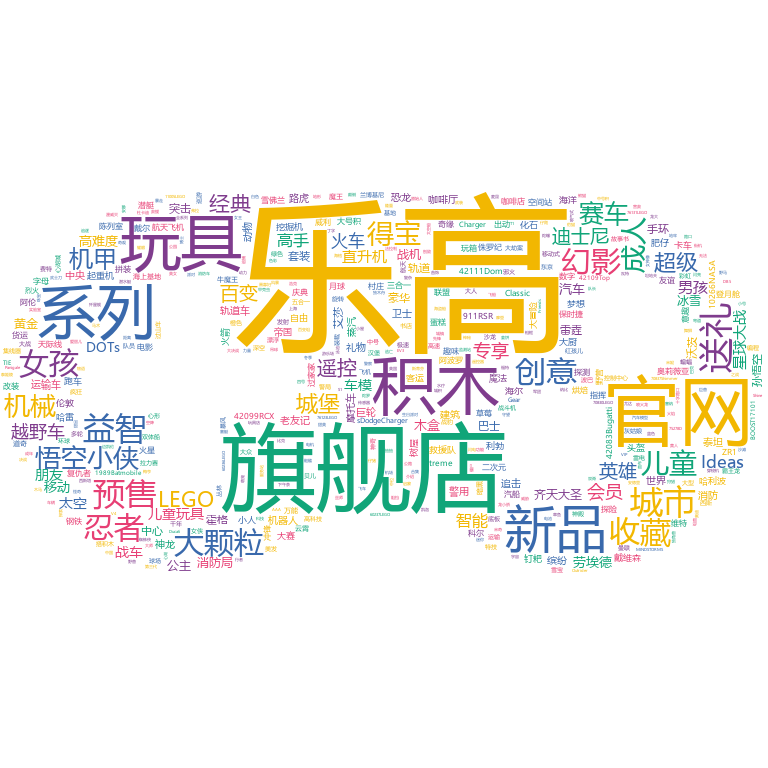

In [34]:
stylecloud.gen_stylecloud(
    text=' '.join(text),
    collocations=False,
    font_path=r'C:\Windows\Fonts\msyh.ttc',
    icon_name='fas fa-gamepad',
    size=768,
    output_name='乐高旗舰店商品标题词云图.png'
)
Image(filename='乐高旗舰店商品标题词云图.png')